In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn

  Using cached matplotlib-3.10.7-cp310-cp310-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp310-cp310-macosx_10_9_universal2.whl.metadata (112 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-12.0.0-cp310-cp310-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 17.2 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 15.6 MB/s  0:00:00 eta 0:00:01
Using cached matplotlib-3.10.7-cp310-cp310-macosx_11_0_arm64.whl (8.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 20.8 MB/s  0:0

Loading dataset: ../data/ml_dataset.csv

===== HEAD =====
           cve_id                published  years_since_published  cvss_score  \
0  CVE-2005-10004  2025-08-30T14:15:32.040                   0.24         8.7   
1  CVE-2008-20001  2025-08-30T14:15:33.533                   0.24         7.5   
2  CVE-2009-20008  2025-08-30T14:15:33.840                   0.24         8.6   
3  CVE-2009-20009  2025-08-30T14:15:34.153                   0.24         9.3   
4  CVE-2009-20010  2025-08-30T14:15:34.877                   0.24         9.3   

  severity  references_count  weaknesses_count  has_windows  has_linux  \
0      NaN                 6                 1            0          0   
1      NaN                 6                 1            1          0   
2      NaN                 6                 1            1          0   
3      NaN                 5                 1            1          0   
4      NaN                 5                 1            0          0   

   has_and

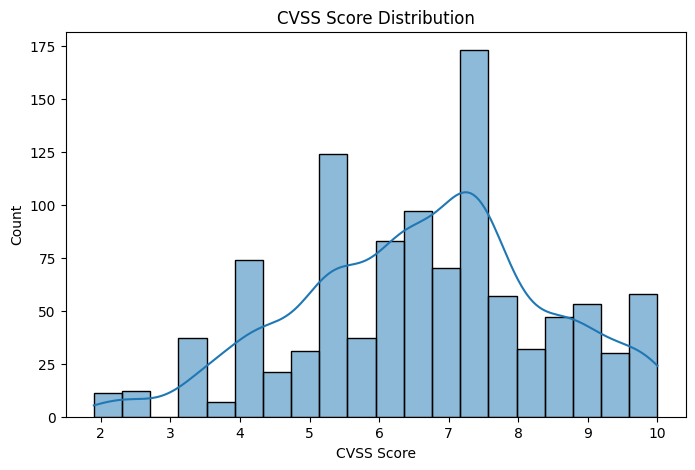

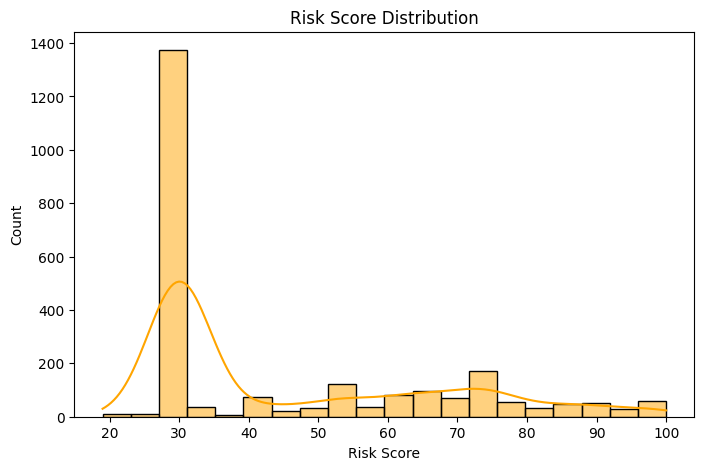

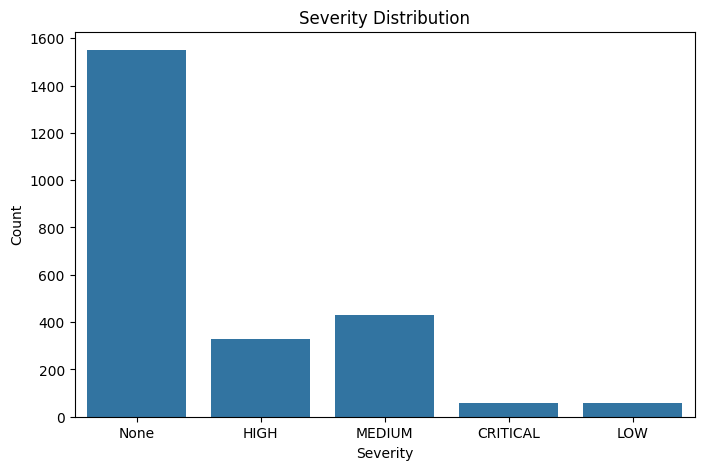

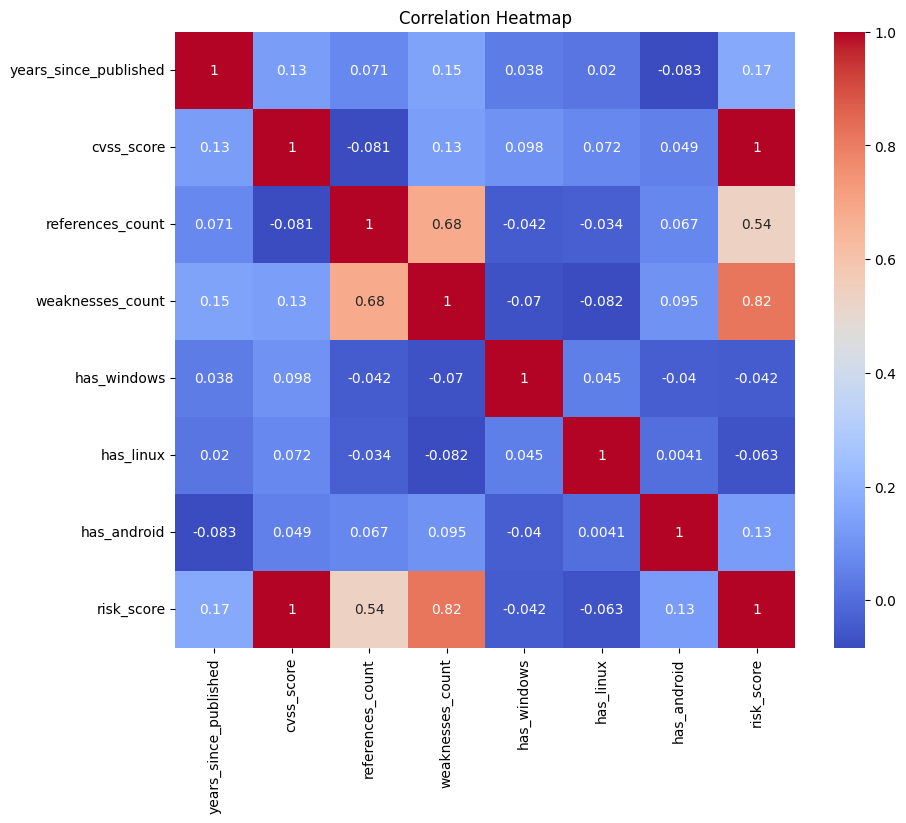

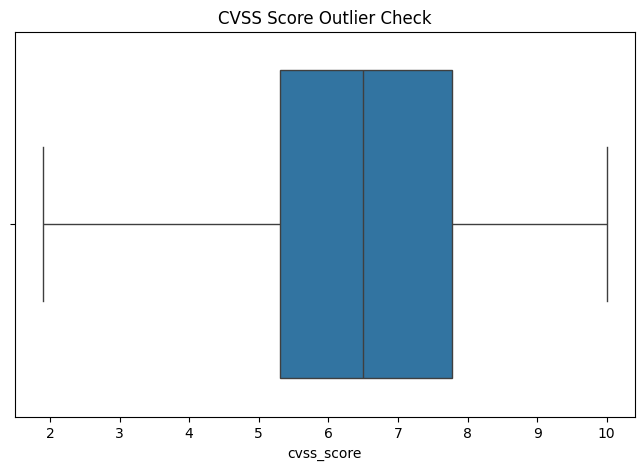

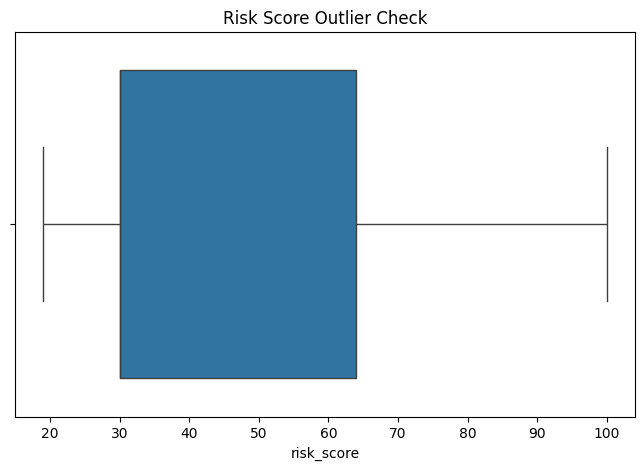

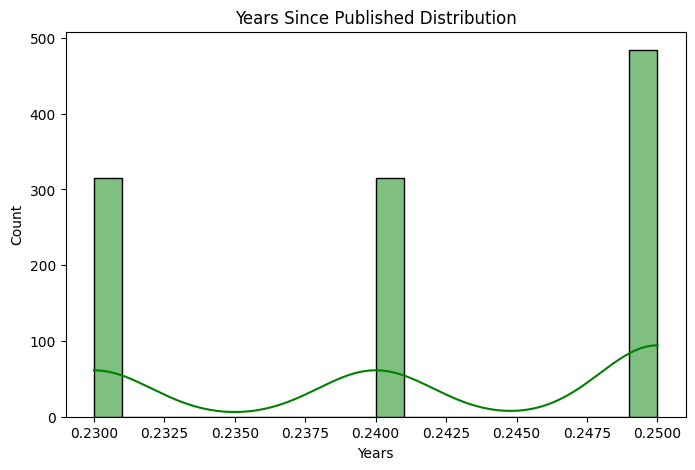


===== TOP 20 WORDS IN DESCRIPTION =====
vulnerability: 2192
this: 2154
file: 920
issue: 907
been: 847
user: 730
attacker: 655
allows: 642
exploit: 611
versions: 603
with: 596
code: 588
affects: 532
attack: 519
from: 510
system: 500
arbitrary: 494
site: 479
could: 467
used: 456

EDA Completed Successfully!


In [5]:
# backend/scripts/eda_ml_dataset.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_FILE = "../data/ml_dataset.csv"

def main():
    print(f"Loading dataset: {DATA_FILE}")
    df = pd.read_csv(DATA_FILE)

    print("\n===== HEAD =====")
    print(df.head())

    print("\n===== SHAPE =====")
    print(df.shape)

    print("\n===== COLUMNS =====")
    print(df.columns)

    print("\n===== MISSING VALUES =====")
    print(df.isna().sum())

    print("\n===== SUMMARY STATISTICS =====")
    print(df.describe(include='all'))

    # -----------------------------
    # CVSS SCORE DISTRIBUTION
    # -----------------------------
    plt.figure(figsize=(8,5))
    sns.histplot(df['cvss_score'], bins=20, kde=True)
    plt.title("CVSS Score Distribution")
    plt.xlabel("CVSS Score")
    plt.ylabel("Count")
    plt.show()

    # -----------------------------
    # RISK SCORE DISTRIBUTION
    # -----------------------------
    plt.figure(figsize=(8,5))
    sns.histplot(df['risk_score'], bins=20, kde=True, color='orange')
    plt.title("Risk Score Distribution")
    plt.xlabel("Risk Score")
    plt.ylabel("Count")
    plt.show()

    # -----------------------------
    # SEVERITY DISTRIBUTION
    # -----------------------------
    plt.figure(figsize=(8,5))
    sns.countplot(x=df['severity'].fillna('None'))
    plt.title("Severity Distribution")
    plt.xlabel("Severity")
    plt.ylabel("Count")
    plt.show()

    # -----------------------------
    # CORRELATION HEATMAP
    # -----------------------------
    plt.figure(figsize=(10,8))
    sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()

    # -----------------------------
    # OUTLIER CHECK (Boxplot)
    # -----------------------------
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df['cvss_score'])
    plt.title("CVSS Score Outlier Check")
    plt.show()

    plt.figure(figsize=(8,5))
    sns.boxplot(x=df['risk_score'])
    plt.title("Risk Score Outlier Check")
    plt.show()

    # -----------------------------
    # YEAR SINCE PUBLISHED DISTRIBUTION
    # -----------------------------
    plt.figure(figsize=(8,5))
    sns.histplot(df['years_since_published'], bins=20, kde=True, color='green')
    plt.title("Years Since Published Distribution")
    plt.xlabel("Years")
    plt.ylabel("Count")
    plt.show()

    # -----------------------------
    # SIMPLE WORD ANALYSIS (TOP WORDS)
    # -----------------------------
    from collections import Counter
    import re

    all_text = " ".join(df['description_text'].dropna().astype(str))
    words = re.findall(r"\b[a-zA-Z]{4,}\b", all_text.lower())

    counter = Counter(words)
    print("\n===== TOP 20 WORDS IN DESCRIPTION =====")
    for word, count in counter.most_common(20):
        print(f"{word}: {count}")

    print("\nEDA Completed Successfully!")

if __name__ == "__main__":
    main()